In [55]:
# Cell 1 - imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.signal import savgol_filter

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [56]:
# Cell 2 - USER SETTINGS

scope_file = r"combined_acq_full\20260323_160136_full_scope_all.npz"
wavemeter_file = r"combined_acq_full\20260323_160136_full_wavemeter.csv"

# -------------------------------------------------
# Wavemeter / TTL alignment
# -------------------------------------------------
ttl_threshold_v = 1.5

# -------------------------------------------------
# Dither suppression
# -------------------------------------------------
bin_size = 10
post_bin_savgol_window = 31
post_bin_savgol_poly = 3

# -------------------------------------------------
# Ramp finding on BINNED data
# -------------------------------------------------
scan_smooth_window = 101
coarse_block = 20
min_ramp_points = 150

edge_fraction = 0.12
eps = 1e-12

display_savgol_window = 3
display_savgol_poly = 1

max_shift = 8

In [57]:
# Cell 3 - loaders

import numpy as np
import pandas as pd

def load_scope_npz(path):
    d = np.load(path)

    t = d["time"]
    probe = d["ch1"]
    ref = d["ch2"]
    ttl = d["ch3"]
    scan = d["ch4"]

    mask = np.isfinite(t) & np.isfinite(probe) & np.isfinite(ref) & np.isfinite(ttl) & np.isfinite(scan)

    out = {
        "t": t[mask],
        "probe": probe[mask],
        "ref": ref[mask],
        "ttl": ttl[mask],
        "scan": scan[mask],
        "t_shot_launch_pc": float(d["t_shot_launch_pc"]),
        "t_shot_launch_perf_ns": int(d["t_shot_launch_perf_ns"]),
    }
    return out

def load_wavemeter_csv(path):
    wm = pd.read_csv(path)
    wm_ok = wm[wm["ok"] == True].copy()
    wm_ok["thz"] = pd.to_numeric(wm_ok["thz"], errors="coerce")
    wm_ok = wm_ok.dropna(subset=["thz"]).copy()

    if len(wm_ok) < 2:
        raise RuntimeError("Not enough valid wavemeter samples")

    wm_ok["t_rel_perf"] = (wm_ok["perf_ns"] - wm_ok["perf_ns"].iloc[0]) * 1e-9
    wm_ok["t_rel_pc"] = wm_ok["pc_time"] - wm_ok["pc_time"].iloc[0]
    return wm_ok

def bin_average_1d(arr, bin_size):
    n = len(arr) // bin_size
    return arr[:n * bin_size].reshape(n, bin_size).mean(axis=1)

In [58]:
# Cell 4 - load combined scope data

scope = load_scope_npz(scope_file)

t_raw = scope["t"]
probe_raw = scope["probe"]
ref_raw = scope["ref"]
ttl_raw = scope["ttl"]
scan_raw = scope["scan"]

print(f"Loaded raw points = {len(t_raw)}")
print(f"Raw probe mean = {np.mean(probe_raw):.6f} V")
print(f"Raw ref mean   = {np.mean(ref_raw):.6f} V")
print(f"Raw scan mean  = {np.mean(scan_raw):.6f} V")
print(f"Raw ttl mean   = {np.mean(ttl_raw):.6f} V")

t     = bin_average_1d(t_raw, bin_size)
probe = bin_average_1d(probe_raw, bin_size)
ref   = bin_average_1d(ref_raw, bin_size)
ttl   = bin_average_1d(ttl_raw, bin_size)
scan  = bin_average_1d(scan_raw, bin_size)

if post_bin_savgol_window >= len(probe):
    post_bin_savgol_window = len(probe) - 1 if len(probe) % 2 == 0 else len(probe)
if post_bin_savgol_window % 2 == 0:
    post_bin_savgol_window -= 1

print(f"Binned points = {len(t)}")
print(f"Binned probe mean = {np.mean(probe):.6f} V")
print(f"Binned ref mean   = {np.mean(ref):.6f} V")
print(f"Binned scan mean  = {np.mean(scan):.6f} V")
print(f"Binned ttl mean   = {np.mean(ttl):.6f} V")

Loaded raw points = 100000
Raw probe mean = 1.014321 V
Raw ref mean   = 0.997055 V
Raw scan mean  = 0.195610 V
Raw ttl mean   = 0.053324 V
Binned points = 10000
Binned probe mean = 1.014321 V
Binned ref mean   = 0.997055 V
Binned scan mean  = 0.195610 V
Binned ttl mean   = 0.053324 V


TTL detected at scope time = 0.978100000 s
Approx TTL in wavemeter perf timebase = 1.588235300 s
Best alignment shift from scan↔freq correlation = 0.213000 s
Best correlation score = 0.997255
Scan↔freq outlier points removed: 0
Interpolated frequency points (raw)   = 100000
Interpolated frequency points (binned)= 10000
Frequency span (binned) = 355.802274013 to 355.803887951 THz
RAW freq stats:
min: 355.802274
max: 355.80388800000003
max index: 24217 time: 2.412 value: 355.80388800000003
min index: 19240 time: 1.9143000000000001 value: 355.802274


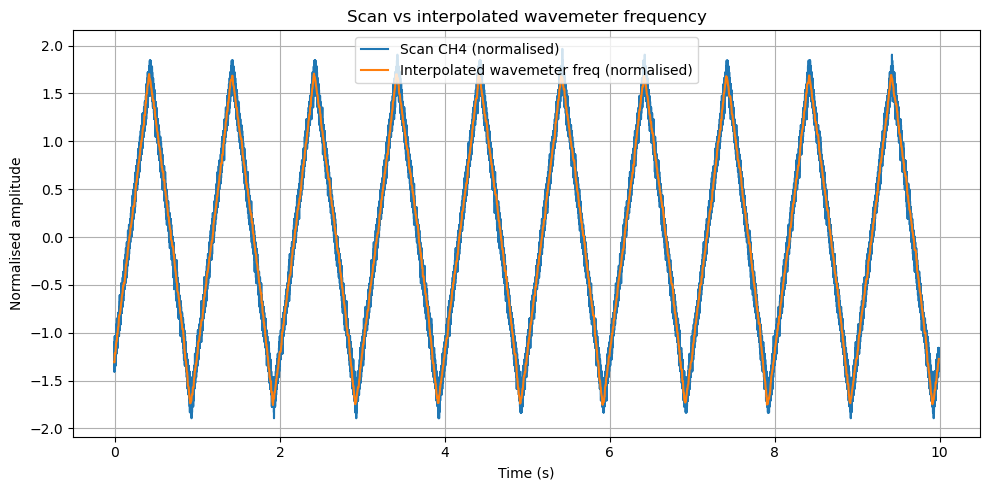

Interpolated frequency points (raw)   = 100000
Interpolated frequency points (binned)= 10000
Frequency span (binned) = 355.802274013 to 355.803887951 THz


In [59]:
# Cell 5 - wavemeter alignment and interpolation onto scope time axis

wm_ok = load_wavemeter_csv(wavemeter_file)

# TTL detection on the RAW scope data, not the binned one
ttl_idx = np.where(ttl_raw > ttl_threshold_v)[0]
if len(ttl_idx) == 0:
    raise RuntimeError("No TTL pulse found in scope CH3")

i_ttl = ttl_idx[0]
t_scope_ttl = float(t_raw[i_ttl])

print(f"TTL detected at scope time = {t_scope_ttl:.9f} s")

# -------------------------------------------------
# 1. Coarse initial guess from shot-launch / TTL
# -------------------------------------------------
t_wm_ttl_approx = (
    (scope["t_shot_launch_perf_ns"] - int(wm_ok["perf_ns"].iloc[0])) * 1e-9
    + t_scope_ttl
)

print(f"Approx TTL in wavemeter perf timebase = {t_wm_ttl_approx:.9f} s")

wm_t = wm_ok["t_rel_perf"].to_numpy(dtype=float)
wm_f = wm_ok["thz"].to_numpy(dtype=float)

# Initial mapping from scope time to wavemeter time
t_scope0_in_wm_guess = t_wm_ttl_approx - t_scope_ttl
t_scope_in_wm_guess = t_scope0_in_wm_guess + t_raw

freq_guess = np.full_like(t_scope_in_wm_guess, np.nan, dtype=float)
valid_guess = (t_scope_in_wm_guess >= wm_t.min()) & (t_scope_in_wm_guess <= wm_t.max())
freq_guess[valid_guess] = np.interp(t_scope_in_wm_guess[valid_guess], wm_t, wm_f)

# -------------------------------------------------
# 2. Refine alignment using scan_raw vs freq_guess
#    We search over a time-shift and maximise correlation
# -------------------------------------------------
def norm_sig(y):
    y = np.asarray(y, dtype=float)
    m = np.isfinite(y)
    if np.sum(m) < 10:
        return y * np.nan
    yy = y.copy()
    yy[~m] = np.nan
    mu = np.nanmean(yy)
    sd = np.nanstd(yy)
    if sd <= 0:
        return yy - mu
    return (yy - mu) / sd

scan_n = norm_sig(scan_raw)

# Search ±0.4 s around the TTL-based guess
shift_grid = np.linspace(-0.4, 0.4, 801)   # 1 ms step
best_shift = 0.0
best_score = -np.inf

for dt in shift_grid:
    t_test = t_scope_in_wm_guess + dt

    f_test = np.full_like(t_test, np.nan, dtype=float)
    m = (t_test >= wm_t.min()) & (t_test <= wm_t.max())
    f_test[m] = np.interp(t_test[m], wm_t, wm_f)

    f_n = norm_sig(f_test)

    good = np.isfinite(scan_n) & np.isfinite(f_n)
    if np.sum(good) < 100:
        continue

    # We expect scan and frequency to have the same shape
    score = np.corrcoef(scan_n[good], f_n[good])[0, 1]

    if np.isfinite(score) and score > best_score:
        best_score = score
        best_shift = dt

print(f"Best alignment shift from scan↔freq correlation = {best_shift:.6f} s")
print(f"Best correlation score = {best_score:.6f}")

# -------------------------------------------------
# 3. Final aligned mapping
# -------------------------------------------------
t_scope_in_wm_raw = t_scope_in_wm_guess + best_shift

freq_interp_raw = np.full_like(t_scope_in_wm_raw, np.nan, dtype=float)
valid = (t_scope_in_wm_raw >= wm_t.min()) & (t_scope_in_wm_raw <= wm_t.max())
freq_interp_raw[valid] = np.interp(t_scope_in_wm_raw[valid], wm_t, wm_f)

# -------------------------------------------------
# Single cleanup pass: remove points inconsistent with scan↔freq relation,
# then smooth once
# -------------------------------------------------
f = freq_interp_raw.copy()

valid_sf = np.isfinite(f) & np.isfinite(scan_raw)
f_valid = f[valid_sf]
scan_valid = scan_raw[valid_sf]
t_valid = t_raw[valid_sf]

# Expected scan↔freq relation
a, b = np.polyfit(scan_valid, f_valid, 1)
f_model = a * scan_valid + b

resid = f_valid - f_model
med = np.nanmedian(resid)
mad = np.nanmedian(np.abs(resid - med))
threshold = 8 * mad

bad = np.abs(resid - med) > threshold

# Expand slightly so the whole bad segment is removed
bad = np.convolve(bad.astype(int), np.ones(5), mode='same') > 0

print("Scan↔freq outlier points removed:", np.sum(bad))
if np.sum(bad) > 0:
    print("Outlier times:", t_valid[bad])
    print("Outlier values:", f_valid[bad])

good = ~bad
if np.sum(good) > 10:
    f_valid[bad] = np.interp(t_valid[bad], t_valid[good], f_valid[good])

f_clean = np.full_like(f, np.nan)
f_clean[valid_sf] = f_valid

# One light NaN-safe smoothing pass
kernel = np.ones(21)

valid2 = np.isfinite(f_clean)
num = np.convolve(np.where(valid2, f_clean, 0.0), kernel, mode='same')
den = np.convolve(valid2.astype(float), kernel, mode='same')

freq_interp_raw = num / den

# Bin once
freq_interp = bin_average_1d(freq_interp_raw, bin_size)

print(f"Interpolated frequency points (raw)   = {np.sum(np.isfinite(freq_interp_raw))}")
print(f"Interpolated frequency points (binned)= {np.sum(np.isfinite(freq_interp))}")
print(f"Frequency span (binned) = {np.nanmin(freq_interp):.9f} to {np.nanmax(freq_interp):.9f} THz")

print("RAW freq stats:")
print("min:", np.nanmin(freq_interp_raw))
print("max:", np.nanmax(freq_interp_raw))

idx_max = np.nanargmax(freq_interp_raw)
idx_min = np.nanargmin(freq_interp_raw)

print("max index:", idx_max, "time:", t_raw[idx_max], "value:", freq_interp_raw[idx_max])
print("min index:", idx_min, "time:", t_raw[idx_min], "value:", freq_interp_raw[idx_min])

# -------------------------------------------------
# Diagnostic: compare raw scan channel to raw interpolated wavemeter frequency
# They should have the same triangular shape vs time.
# -------------------------------------------------
plt.figure(figsize=(10, 5))

# Normalise both for shape comparison only
def safe_norm(y):
    y = np.asarray(y, dtype=float)
    m = np.isfinite(y)
    if np.sum(m) < 10:
        return y * np.nan

    mu = np.nanmean(y[m])
    sd = np.nanstd(y[m])
    if sd <= 0:
        return y - mu

    out = (y - mu) / sd
    out[~m] = np.nan
    return out

scan_norm = safe_norm(scan_raw)
freq_norm = safe_norm(freq_interp_raw)

plt.plot(t_raw, scan_norm, label="Scan CH4 (normalised)")
plt.plot(t_raw, freq_norm, label="Interpolated wavemeter freq (normalised)")

plt.xlabel("Time (s)")
plt.ylabel("Normalised amplitude")
plt.title("Scan vs interpolated wavemeter frequency")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Interpolated frequency points (raw)   = {np.sum(np.isfinite(freq_interp_raw))}")
print(f"Interpolated frequency points (binned)= {np.sum(np.isfinite(freq_interp))}")
print(f"Frequency span (binned) = {np.nanmin(freq_interp):.9f} to {np.nanmax(freq_interp):.9f} THz")

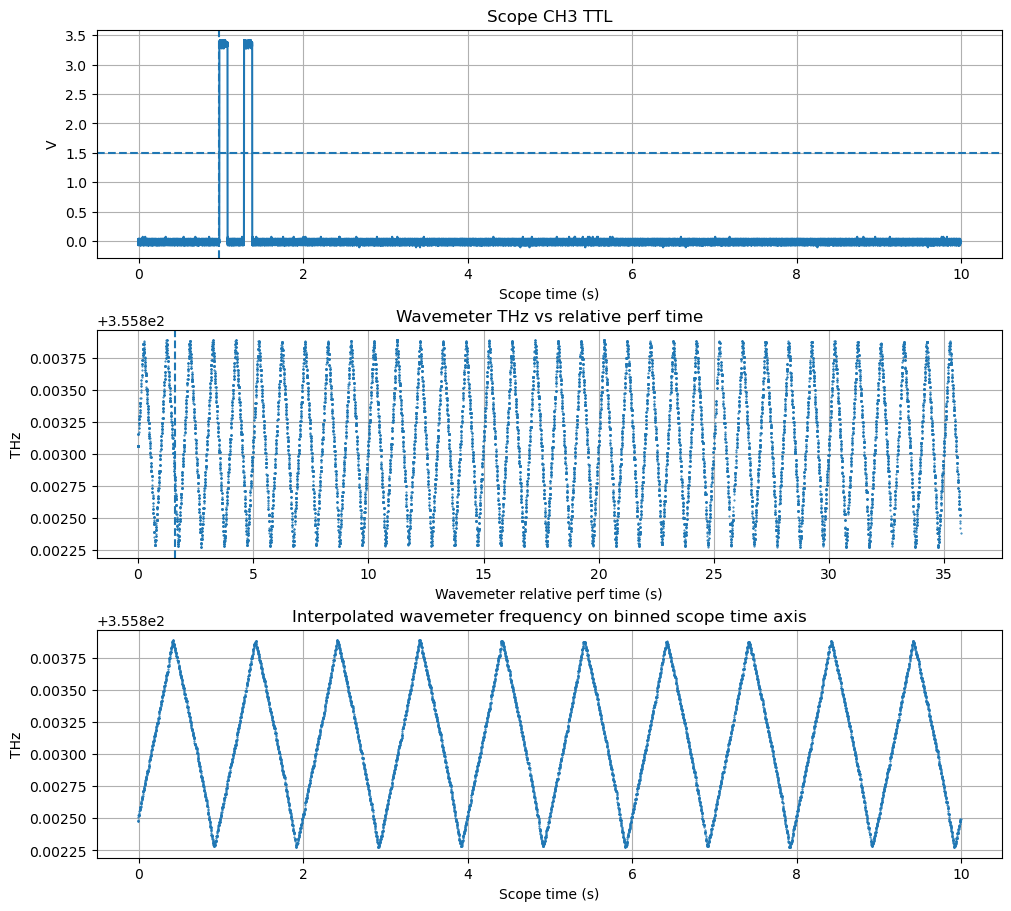

In [60]:
# Cell 5a - sanity plots for alignment

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 9), constrained_layout=True)

axes[0].plot(t_raw, ttl_raw)
axes[0].axhline(ttl_threshold_v, linestyle="--")
axes[0].axvline(t_scope_ttl, linestyle="--")
axes[0].set_title("Scope CH3 TTL")
axes[0].set_xlabel("Scope time (s)")
axes[0].set_ylabel("V")

axes[1].plot(wm_ok["t_rel_perf"], wm_ok["thz"], ".", ms=1)
axes[1].axvline(t_wm_ttl_approx, linestyle="--")
axes[1].set_title("Wavemeter THz vs relative perf time")
axes[1].set_xlabel("Wavemeter relative perf time (s)")
axes[1].set_ylabel("THz")

axes[2].plot(t, freq_interp, ".", ms=1)
axes[2].set_title("Interpolated wavemeter frequency on binned scope time axis")
axes[2].set_xlabel("Scope time (s)")
axes[2].set_ylabel("THz")

plt.show()

In [61]:
# Cell 5b - smooth scan and coarse derivative for ramp finding

if scan_smooth_window >= len(scan):
    scan_smooth_window = len(scan) - 1 if len(scan) % 2 == 0 else len(scan)
if scan_smooth_window % 2 == 0:
    scan_smooth_window -= 1

scan_smooth = savgol_filter(scan, scan_smooth_window, 3)

n_coarse = len(scan_smooth) // coarse_block
scan_coarse = scan_smooth[:n_coarse * coarse_block].reshape(n_coarse, coarse_block).mean(axis=1)
dscan_coarse = np.diff(scan_coarse, prepend=scan_coarse[0])

print(f"scan_smooth length = {len(scan_smooth)}")
print(f"scan_coarse length = {len(scan_coarse)}")

scan_smooth length = 10000
scan_coarse length = 500


rise_threshold = 3.025956e-03
Found 8 rising ramps


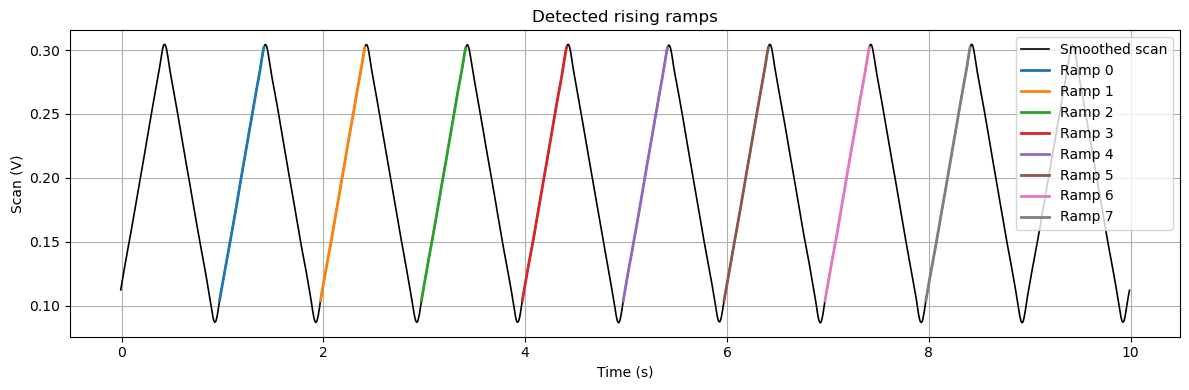

In [62]:
# Cell 6 - Rising ramps using a stricter derivative threshold

# -------------------------------------------------
# USER SETTINGS FOR RAMP DETECTION
# -------------------------------------------------
rise_threshold_fraction = 0.30   # 0.2 to 0.4 is a good range
edge_trim_blocks = 1             # trim 1 coarse block from each end
drop_edge_ramps = True           # drop first and last incomplete ramps

# -------------------------------------------------
# 1. Build a stricter rising-state mask
# -------------------------------------------------
positive_d = dscan_coarse[dscan_coarse > 0]

if len(positive_d) == 0:
    raise RuntimeError("No positive scan derivative points found")

rise_threshold = rise_threshold_fraction * np.nanmax(positive_d)

print(f"rise_threshold = {rise_threshold:.6e}")

rising_state = dscan_coarse > rise_threshold

# -------------------------------------------------
# 2. Find contiguous rising regions in coarse indices
# -------------------------------------------------
rising_ramps_coarse = []
in_run = False
start_idx = None

for i, state in enumerate(rising_state):
    if state and not in_run:
        in_run = True
        start_idx = i
    elif not state and in_run:
        rising_ramps_coarse.append((start_idx, i - 1))
        in_run = False

if in_run:
    rising_ramps_coarse.append((start_idx, len(rising_state) - 1))

# -------------------------------------------------
# 3. Convert coarse regions to fine slices
#    and trim the edges of each ramp slightly
# -------------------------------------------------
ramp_slices = []

for a, b in rising_ramps_coarse:
    start = a * coarse_block
    end = min((b + 1) * coarse_block, len(scan_smooth))   # end stays exclusive for slicing

    # trim each side by a fixed number of coarse blocks
    start += edge_trim_blocks * coarse_block
    end   -= edge_trim_blocks * coarse_block

    if (end - start) >= min_ramp_points:
        ramp_slices.append(slice(start, end))

# -------------------------------------------------
# 4. Drop incomplete first/last ramps if requested
# -------------------------------------------------
if drop_edge_ramps and len(ramp_slices) >= 3:
    ramp_slices = ramp_slices[1:-1]

print(f"Found {len(ramp_slices)} rising ramps")

# -------------------------------------------------
# 5. Plot detected ramps
# -------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(t, scan_smooth, color="black", lw=1.2, label="Smoothed scan")

for i, r in enumerate(ramp_slices):
    plt.plot(t[r], scan_smooth[r], lw=2, label=f"Ramp {i}")

plt.xlabel("Time (s)")
plt.ylabel("Scan (V)")
plt.title("Detected rising ramps")
plt.legend()
plt.tight_layout()
plt.show()

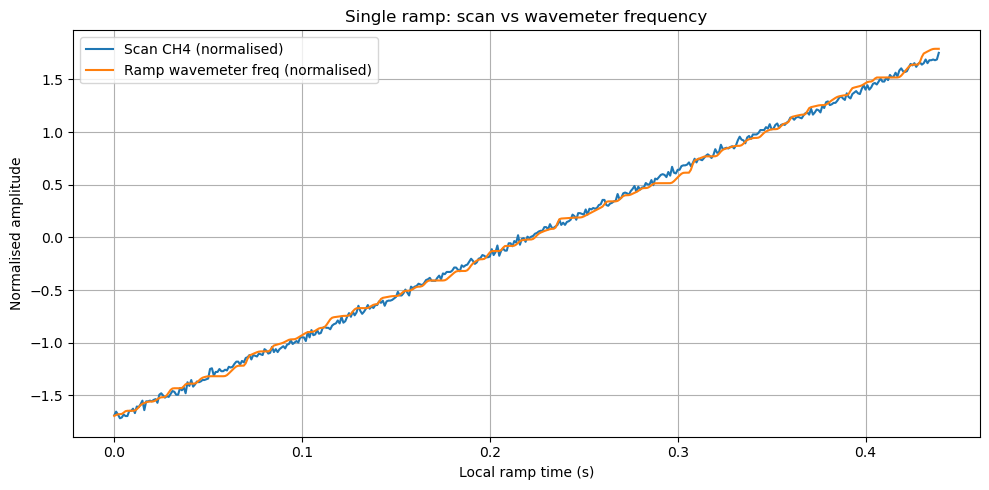

In [63]:
# New diagnostic cell - zoom into one interior detected ramp

r = ramp_slices[3]   # choose an interior ramp

plt.figure(figsize=(10, 5))

scan_seg = scan[r]
freq_seg = freq_interp[r]

scan_seg_norm = safe_norm(scan_seg)
freq_seg_norm = safe_norm(freq_seg)

t_local = t[r] - t[r][0]

plt.plot(t_local, scan_seg_norm, label="Scan CH4 (normalised)")
plt.plot(t_local, freq_seg_norm, label="Ramp wavemeter freq (normalised)")

plt.xlabel("Local ramp time (s)")
plt.ylabel("Normalised amplitude")
plt.title("Single ramp: scan vs wavemeter frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# Cell 7 - processing function

def process_rising_ramp(t_r, scan_r, freq_r, probe_r, ref_r, edge_fraction=0.12, eps=1e-12, max_shift=8):
    """
    Process one rising ramp with automatic small probe/ref sample alignment.

    IMPORTANT:
    - Ramp detection has already been done using the scan channel.
    - We KEEP the ramp in its original time order.
    - We do NOT sort by frequency here.
    - We do NOT delete points here.
    - Frequency is just an axis label attached to each measured sample.
    """

    # -------------------------------------------------
    # 1. Find best small integer shift between probe and ref
    #    using ramp edges in time order
    # -------------------------------------------------
    n0 = len(scan_r)
    n_edge0 = max(10, int(edge_fraction * n0))
    edge_idx0 = np.r_[np.arange(n_edge0), np.arange(n0 - n_edge0, n0)]

    best_shift = 0
    best_score = np.inf

    for s in range(-max_shift, max_shift + 1):
        p_test = np.roll(probe_r, s)

        p_edge = p_test[edge_idx0]
        r_edge = ref_r[edge_idx0]

        k_test = np.mean(p_edge) / np.mean(r_edge)
        resid = p_edge - k_test * r_edge
        score = np.std(resid)

        if score < best_score:
            best_score = score
            best_shift = s

    # Apply best shift to probe
    probe_r = np.roll(probe_r, best_shift)

    # -------------------------------------------------
    # 2. Keep only finite points
    # -------------------------------------------------
    valid = (
        np.isfinite(freq_r)
        & np.isfinite(scan_r)
        & np.isfinite(probe_r)
        & np.isfinite(ref_r)
        & np.isfinite(t_r)
    )

    tt = t_r[valid]
    x_scan = scan_r[valid]
    x_freq = freq_r[valid]
    p = probe_r[valid]
    r = ref_r[valid]

    print(f"Original N = {len(freq_r)}, after valid filter = {np.sum(valid)}")

    n = len(x_scan)
    if n < 20:
        raise RuntimeError("Ramp has too few valid points after frequency filtering")

    n_edge = max(20, int(edge_fraction * n))

    # -------------------------------------------------
    # 3. Scale reference to probe using ramp edges
    #    IMPORTANT: edges are defined in TIME ORDER, not sorted order
    # -------------------------------------------------
    probe_edges = np.r_[p[:n_edge], p[-n_edge:]]
    ref_edges   = np.r_[r[:n_edge], r[-n_edge:]]

    k = np.mean(probe_edges) / np.mean(ref_edges)
    ref_scaled = k * r

    # -------------------------------------------------
    # 4. Build signals
    # -------------------------------------------------
    ratio = ref_scaled / (p + eps)
    od = np.log(ratio)
    diff = p - ref_scaled

    # -------------------------------------------------
    # 5. Baseline from edges in TIME (not frequency)
    # -------------------------------------------------

    t_edge = np.r_[tt[:n_edge], tt[-n_edge:]]

    od_edge = np.r_[od[:n_edge], od[-n_edge:]]
    ratio_edge = np.r_[ratio[:n_edge], ratio[-n_edge:]]
    diff_edge = np.r_[diff[:n_edge], diff[-n_edge:]]

    # centre time for stability
    t0 = np.mean(t_edge)
    t_edge_c = t_edge - t0
    tt_c = tt - t0

    # fit baseline vs TIME
    od_coeff = np.polyfit(t_edge_c, od_edge, 1)
    od_baseline = np.polyval(od_coeff, tt_c)
    od_corr = od - od_baseline

    ratio_coeff = np.polyfit(t_edge_c, ratio_edge, 1)
    ratio_baseline = np.polyval(ratio_coeff, tt_c)
    ratio_corr = ratio / ratio_baseline

    diff_coeff = np.polyfit(t_edge_c, diff_edge, 1)
    diff_baseline = np.polyval(diff_coeff, tt_c)
    diff_corr = diff - diff_baseline

    return {
        "t": tt,
        "scan": x_scan,
        "freq": x_freq,
        "probe": p,
        "ref": r,
        "k": k,
        "best_shift": best_shift,
        "shift_score": best_score,
        "ref_scaled": ref_scaled,
        "ratio": ratio,
        "ratio_baseline": ratio_baseline,
        "ratio_corr": ratio_corr,
        "od": od,
        "od_baseline": od_baseline,
        "od_corr": od_corr,
        "diff": diff,
        "diff_baseline": diff_baseline,
        "diff_corr": diff_corr,
    }

In [65]:
from scipy.signal import savgol_filter
import numpy as np

def longest_true_run(mask):
    best_start = None
    best_stop = None
    start = None

    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            if best_start is None or (i - start) > (best_stop - best_start):
                best_start, best_stop = start, i
            start = None

    if start is not None:
        i = len(mask)
        if best_start is None or (i - start) > (best_stop - best_start):
            best_start, best_stop = start, i

    if best_start is None:
        return 0, len(mask)

    return best_start, best_stop


def trim_to_strict_rising(r, scan_array, frac_of_max_slope=0.35, pad_points=3):
    idx = np.arange(r.start, r.stop)
    y = scan_array[idx]

    win = min(31, len(y) - (1 - len(y) % 2))
    if win < 5:
        return r

    if win % 2 == 0:
        win -= 1

    y_s = savgol_filter(y, win, 2)
    dy = np.gradient(y_s)

    thresh = frac_of_max_slope * np.nanmax(dy)
    good = dy > thresh

    i0, i1 = longest_true_run(good)

    i0 = max(0, i0 - pad_points)
    i1 = min(len(idx), i1 + pad_points)

    return slice(r.start + i0, r.start + i1)

In [66]:
# Cell 8 - process ramps

# Use only complete interior ramps, no adaptive trimming
ramp_slices_use = ramp_slices

processed = []
for r in ramp_slices_use:
    processed.append(
        process_rising_ramp(
            t[r],
            scan[r],
            freq_interp[r],
            probe[r],
            ref[r],
            edge_fraction=edge_fraction,
            eps=eps,
            max_shift=max_shift
        )
    )

k_values = np.array([p["k"] for p in processed])

print(f"Processed {len(processed)} rising ramps")
print(f"k mean = {np.mean(k_values):.6f}")
print(f"k std  = {np.std(k_values):.6f}")

shift_values = np.array([p["best_shift"] for p in processed])
print(f"Best shifts per ramp = {shift_values.tolist()}")

Original N = 440, after valid filter = 440
Original N = 440, after valid filter = 440
Original N = 440, after valid filter = 440
Original N = 440, after valid filter = 440
Original N = 440, after valid filter = 440
Original N = 440, after valid filter = 440
Original N = 440, after valid filter = 440
Original N = 440, after valid filter = 440
Processed 8 rising ramps
k mean = 1.016610
k std  = 0.000647
Best shifts per ramp = [0, 0, 0, 0, 0, 0, 0, 0]


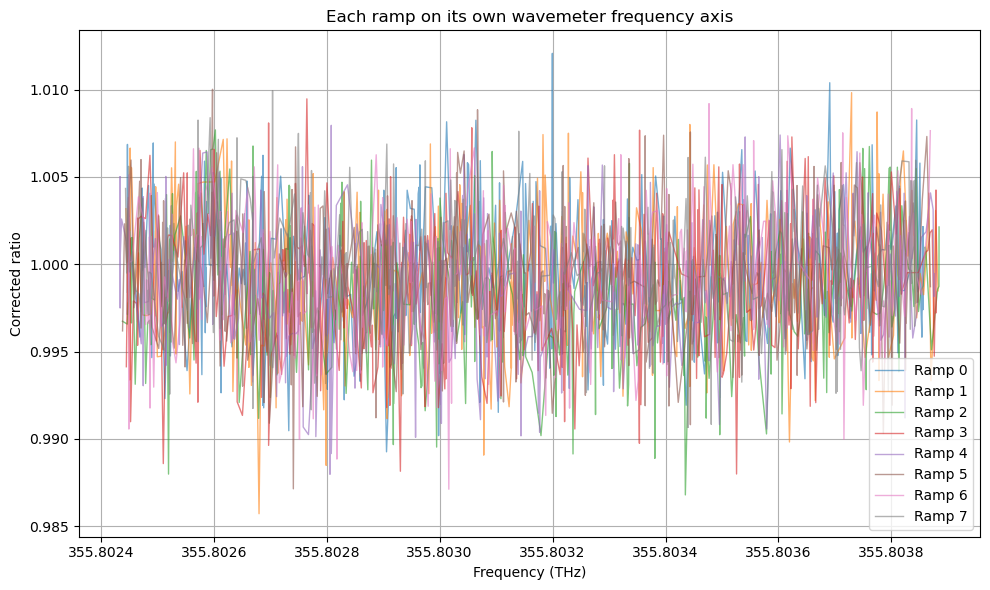

In [67]:
plt.figure(figsize=(10,6))
for i, p in enumerate(processed):
    plt.plot(p["freq"], p["ratio_corr"], lw=1, alpha=0.6, label=f"Ramp {i}")
plt.xlabel("Frequency (THz)")
plt.ylabel("Corrected ratio")
plt.title("Each ramp on its own wavemeter frequency axis")
if len(processed) <= 12:
    plt.legend()
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show()

Per-ramp summary
----------------
Ramp  0 | N =  440 | k = 1.018059 | best_shift =  0 | shift_score = 3.320758e-03
Ramp  1 | N =  440 | k = 1.016894 | best_shift =  0 | shift_score = 4.000006e-03
Ramp  2 | N =  440 | k = 1.016112 | best_shift =  0 | shift_score = 3.940446e-03
Ramp  3 | N =  440 | k = 1.016657 | best_shift =  0 | shift_score = 3.799922e-03
Ramp  4 | N =  440 | k = 1.015983 | best_shift =  0 | shift_score = 3.456988e-03
Ramp  5 | N =  440 | k = 1.016337 | best_shift =  0 | shift_score = 3.812557e-03
Ramp  6 | N =  440 | k = 1.016852 | best_shift =  0 | shift_score = 4.070587e-03
Ramp  7 | N =  440 | k = 1.015985 | best_shift =  0 | shift_score = 3.812702e-03

Selected ramp
-------------
Ramp index   = 1
N points     = 440
k            = 1.016894
best_shift   = 0
shift_score  = 4.000006e-03


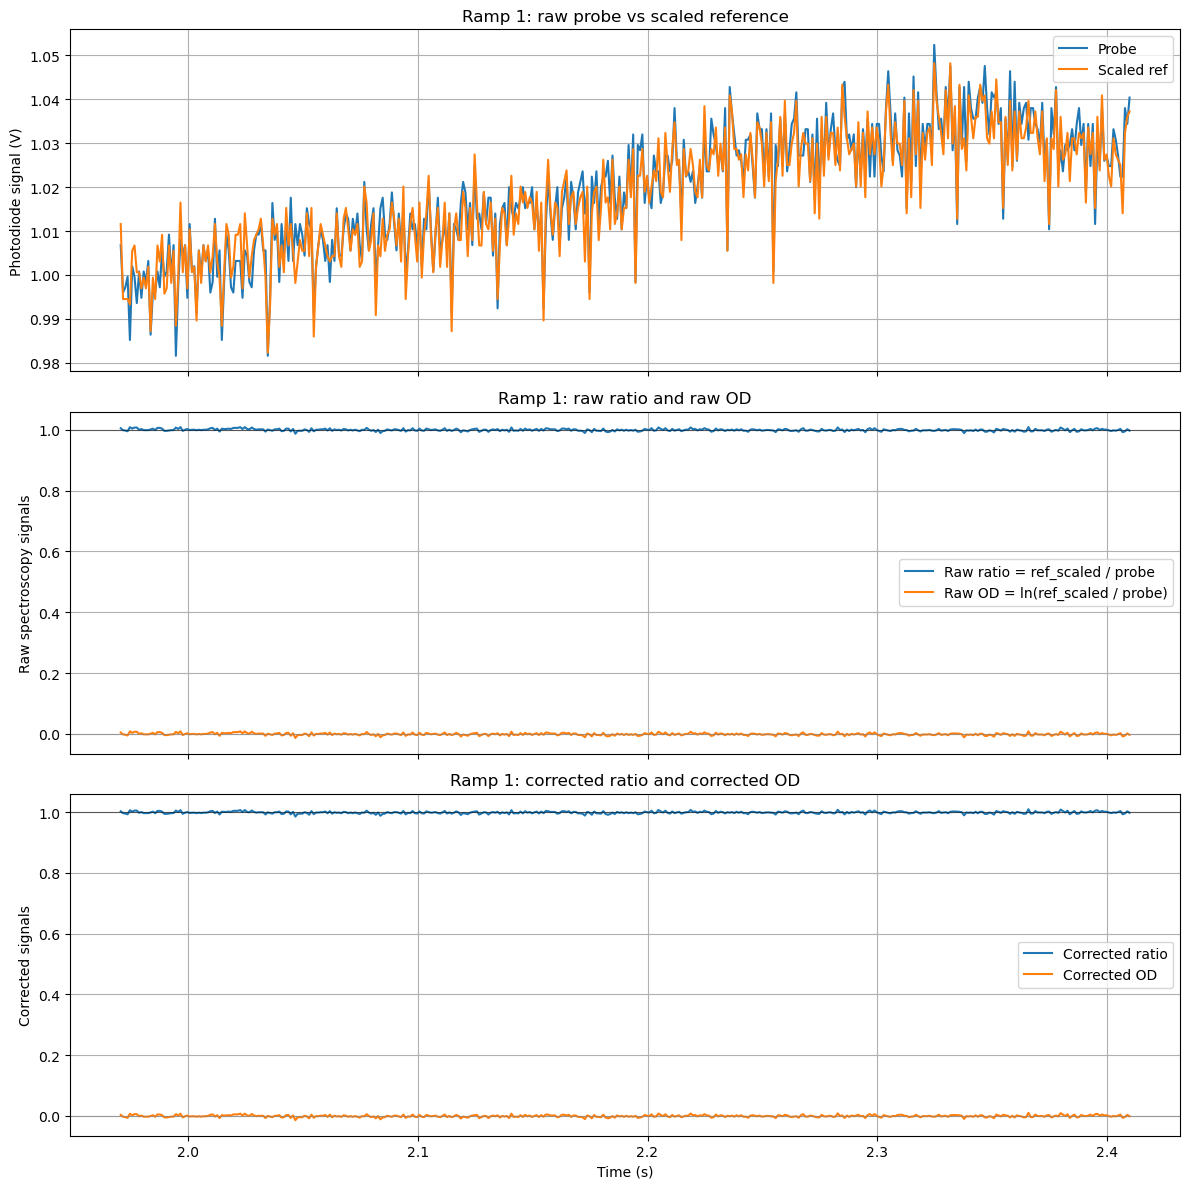

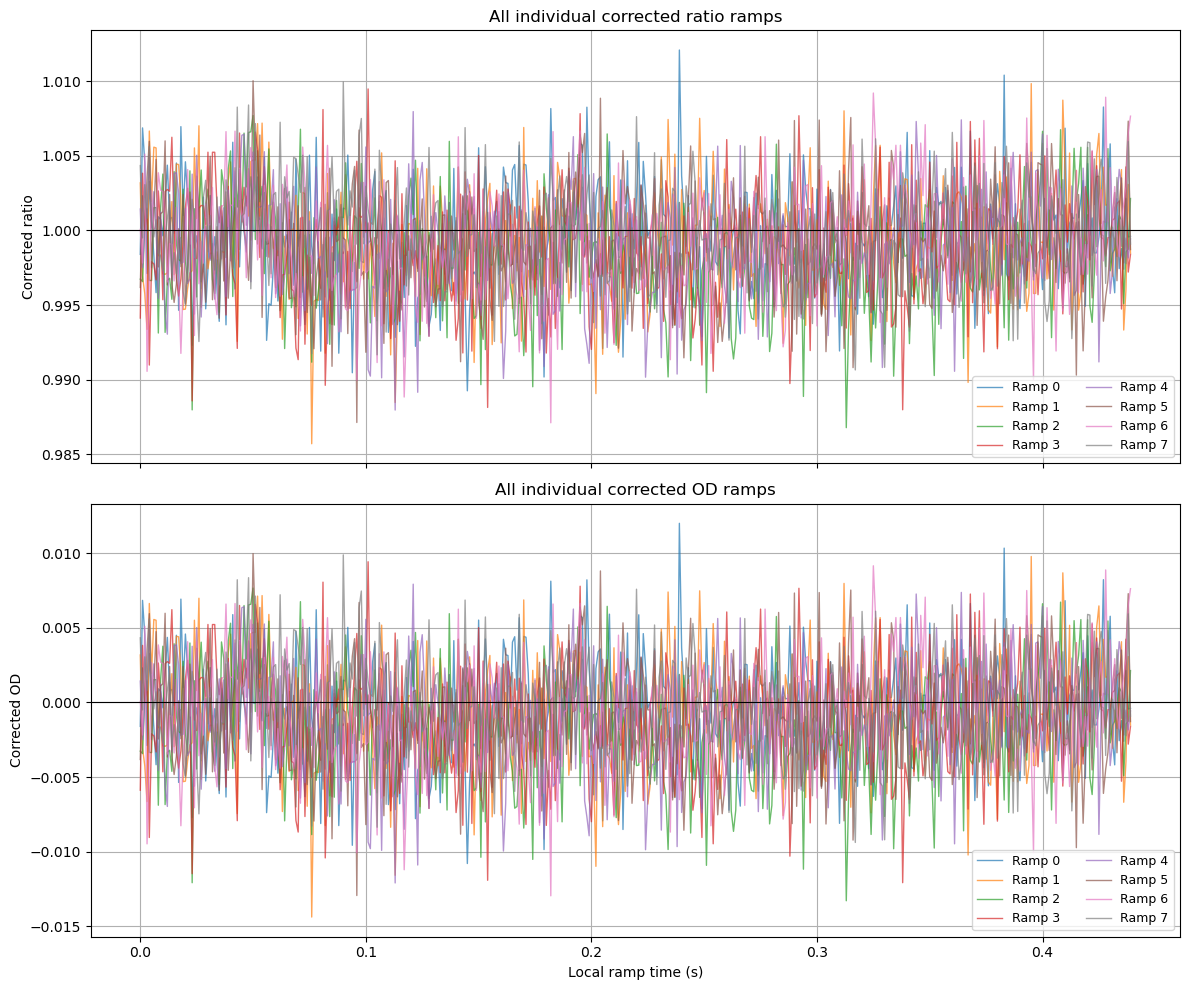

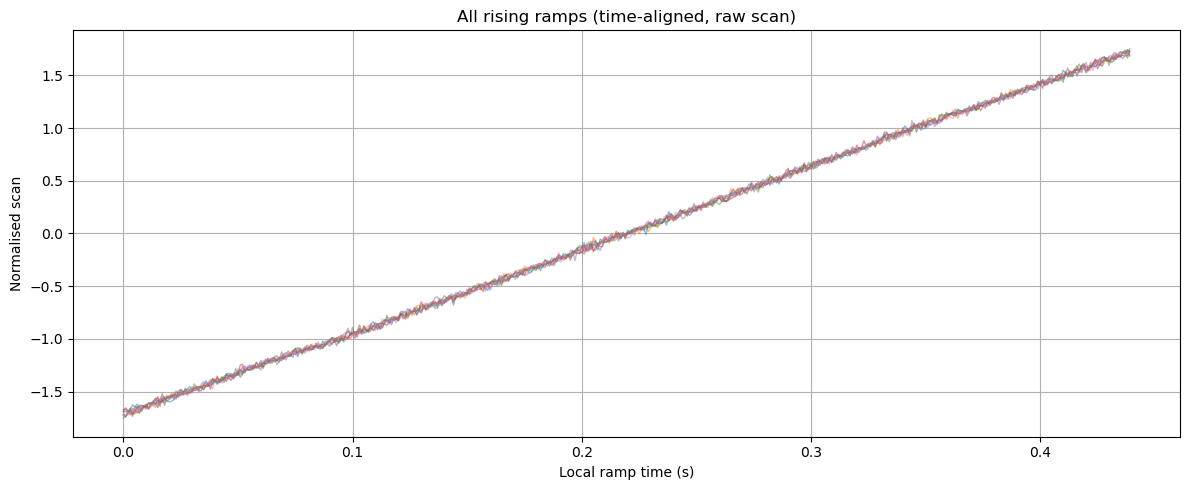

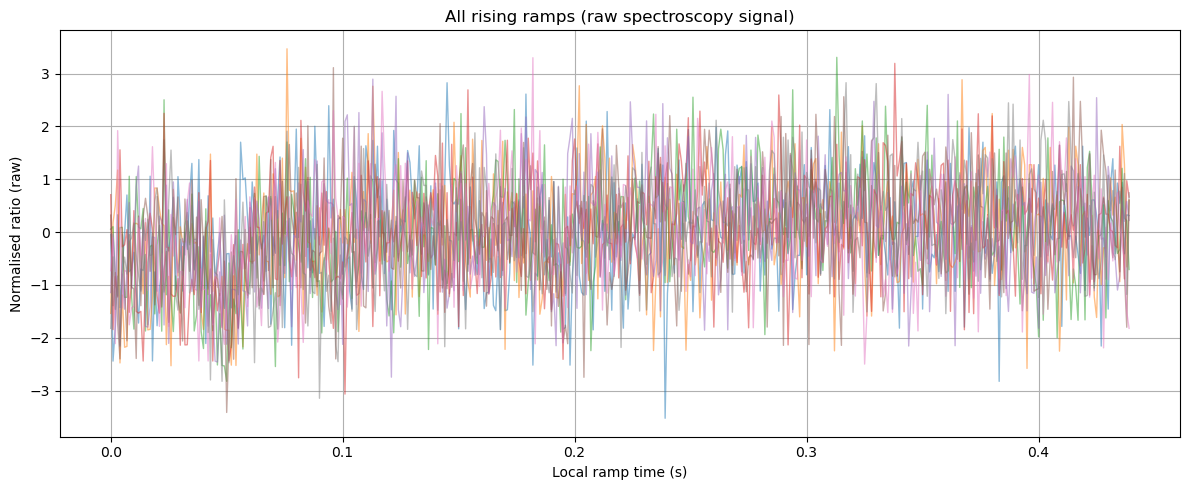

In [68]:
# Cell 8A - inspect individual rising ramps before averaging

# -------------------------------------------------
# USER CHOICE
# -------------------------------------------------
ramp_index = 1          # change this to inspect different ramps
show_all_ramps = True  # set True to overlay all ramps in one plot

if len(processed) == 0:
    raise RuntimeError("No processed ramps found. Run Cell 8 first.")

if ramp_index < 0 or ramp_index >= len(processed):
    raise IndexError(f"ramp_index must be between 0 and {len(processed)-1}")

# -------------------------------------------------
# 1. Print summary for each ramp
# -------------------------------------------------
print("Per-ramp summary")
print("----------------")
for i, p in enumerate(processed):
    print(
        f"Ramp {i:2d} | "
        f"N = {len(p['freq']):4d} | "
        f"k = {p['k']:.6f} | "
        f"best_shift = {p['best_shift']:2d} | "
        f"shift_score = {p['shift_score']:.6e}"
    )

# -------------------------------------------------
# 2. Inspect one selected ramp in detail
# -------------------------------------------------
p = processed[ramp_index]

print("\nSelected ramp")
print("-------------")
print(f"Ramp index   = {ramp_index}")
print(f"N points     = {len(p['freq'])}")
print(f"k            = {p['k']:.6f}")
print(f"best_shift   = {p['best_shift']}")
print(f"shift_score  = {p['shift_score']:.6e}")

fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# -------------------------------------------------
# Top panel: raw probe and scaled ref for this ramp
# -------------------------------------------------
ax[0].plot(p["t"], p["probe"], label="Probe", lw=1.5)
ax[0].plot(p["t"], p["ref_scaled"], label="Scaled ref", lw=1.5)
ax[0].set_ylabel("Photodiode signal (V)")
ax[0].set_title(f"Ramp {ramp_index}: raw probe vs scaled reference")
ax[0].legend()

# -------------------------------------------------
# Middle panel: uncorrected signals
# -------------------------------------------------
ax[1].plot(p["t"], p["ratio"], label="Raw ratio = ref_scaled / probe", lw=1.5)
ax[1].plot(p["t"], p["od"], label="Raw OD = ln(ref_scaled / probe)", lw=1.5)
ax[1].axhline(1.0, color="black", lw=0.8, alpha=0.5)
ax[1].axhline(0.0, color="grey", lw=0.8, alpha=0.5)
ax[1].set_ylabel("Raw spectroscopy signals")
ax[1].set_title(f"Ramp {ramp_index}: raw ratio and raw OD")
ax[1].legend()

# -------------------------------------------------
# Bottom panel: corrected signals
# -------------------------------------------------
ax[2].plot(p["t"], p["ratio_corr"], label="Corrected ratio", lw=1.5)
ax[2].plot(p["t"], p["od_corr"], label="Corrected OD", lw=1.5)
ax[2].axhline(1.0, color="black", lw=0.8, alpha=0.5)
ax[2].axhline(0.0, color="grey", lw=0.8, alpha=0.5)
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Corrected signals")
ax[2].set_title(f"Ramp {ramp_index}: corrected ratio and corrected OD")
ax[2].legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3. Optional: overlay all corrected ramps without averaging
# -------------------------------------------------
if show_all_ramps:
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    for i, p in enumerate(processed):
        t_local = p["t"] - p["t"][0]
        ax[0].plot(t_local, p["ratio_corr"], alpha=0.7, lw=1.0, label=f"Ramp {i}")
        ax[1].plot(t_local, p["od_corr"], alpha=0.7, lw=1.0, label=f"Ramp {i}")

    ax[0].axhline(1.0, color="black", lw=0.8)
    ax[1].axhline(0.0, color="black", lw=0.8)

    ax[0].set_ylabel("Corrected ratio")
    ax[0].set_title("All individual corrected ratio ramps")
    ax[1].set_ylabel("Corrected OD")
    ax[1].set_xlabel("Local ramp time (s)")
    ax[1].set_title("All individual corrected OD ramps")

    if len(processed) <= 12:
        ax[0].legend(ncol=2, fontsize=9)
        ax[1].legend(ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

# -------------------------------------------------
# Diagnostic: overlay all ramps (RAW, time domain)
# -------------------------------------------------

plt.figure(figsize=(12, 5))

for i, r in enumerate(ramp_slices):
    t_local = t[r] - t[r][0]
    scan_seg = scan[r]
    
    # normalise each ramp for comparison
    scan_seg_norm = safe_norm(scan_seg)
    
    plt.plot(t_local, scan_seg_norm, alpha=0.5, lw=1)

plt.xlabel("Local ramp time (s)")
plt.ylabel("Normalised scan")
plt.title("All rising ramps (time-aligned, raw scan)")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Diagnostic: overlay all ramps (RAW ratio signal)
# -------------------------------------------------

plt.figure(figsize=(12, 5))

for i, r in enumerate(ramp_slices):
    t_local = t[r] - t[r][0]
    
    ratio_seg = (probe[r] / ref[r])  # raw ratio
    
    # remove obvious outliers / infs
    ratio_seg = np.where(np.isfinite(ratio_seg), ratio_seg, np.nan)
    
    # normalise for visibility
    ratio_seg_norm = safe_norm(ratio_seg)
    
    plt.plot(t_local, ratio_seg_norm, alpha=0.5, lw=1)

plt.xlabel("Local ramp time (s)")
plt.ylabel("Normalised ratio (raw)")
plt.title("All rising ramps (raw spectroscopy signal)")
plt.tight_layout()
plt.show()

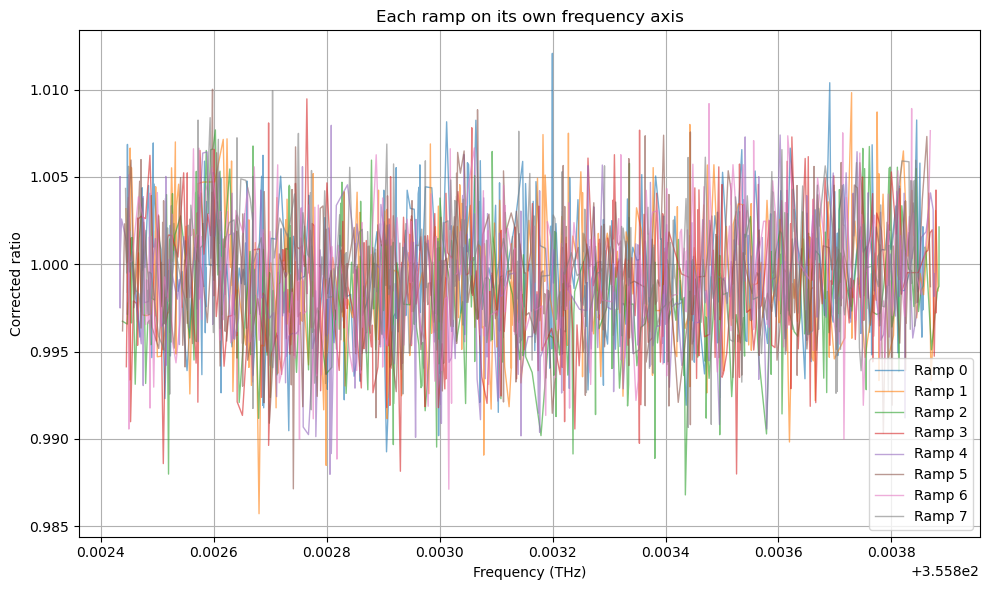

In [69]:
# New diagnostic cell - each ramp on its own frequency axis for display only

plt.figure(figsize=(10, 6))

for i, p in enumerate(processed):
    order = np.argsort(p["freq"])
    plt.plot(p["freq"][order], p["ratio_corr"][order], lw=1, alpha=0.6, label=f"Ramp {i}")

plt.xlabel("Frequency (THz)")
plt.ylabel("Corrected ratio")
plt.title("Each ramp on its own frequency axis")
if len(processed) <= 12:
    plt.legend()
plt.tight_layout()
plt.show()

In [70]:
# Cell 9 - Common x-axis in wavemeter frequency

x_min = max(np.nanmin(p["freq"]) for p in processed)
x_max = min(np.nanmax(p["freq"]) for p in processed)

# Use a more reasonable density first
common_x = np.linspace(x_min, x_max, 1200)

ratio_corr_matrix = []
od_corr_matrix = []
diff_corr_matrix = []

for p in processed:
    f = np.asarray(p["freq"], dtype=float)
    y_ratio = np.asarray(p["ratio_corr"], dtype=float)
    y_od = np.asarray(p["od_corr"], dtype=float)
    y_diff = np.asarray(p["diff_corr"], dtype=float)

    # Keep only finite points
    m = np.isfinite(f) & np.isfinite(y_ratio) & np.isfinite(y_od) & np.isfinite(y_diff)
    f = f[m]
    y_ratio = y_ratio[m]
    y_od = y_od[m]
    y_diff = y_diff[m]

    # Sort by frequency ONLY here, for interpolation onto common axis
    order = np.argsort(f)
    f = f[order]
    y_ratio = y_ratio[order]
    y_od = y_od[order]
    y_diff = y_diff[order]

    # Collapse duplicate frequency values by averaging
    f_unique, inv = np.unique(f, return_inverse=True)

    ratio_unique = np.zeros_like(f_unique, dtype=float)
    od_unique = np.zeros_like(f_unique, dtype=float)
    diff_unique = np.zeros_like(f_unique, dtype=float)
    counts = np.zeros_like(f_unique, dtype=float)

    for i, j in enumerate(inv):
        ratio_unique[j] += y_ratio[i]
        od_unique[j] += y_od[i]
        diff_unique[j] += y_diff[i]
        counts[j] += 1

    ratio_unique /= counts
    od_unique /= counts
    diff_unique /= counts

    ratio_corr_matrix.append(np.interp(common_x, f_unique, ratio_unique))
    od_corr_matrix.append(np.interp(common_x, f_unique, od_unique))
    diff_corr_matrix.append(np.interp(common_x, f_unique, diff_unique))

ratio_corr_matrix = np.array(ratio_corr_matrix)
od_corr_matrix = np.array(od_corr_matrix)
diff_corr_matrix = np.array(diff_corr_matrix)

ratio_mean = np.mean(ratio_corr_matrix, axis=0)
ratio_std  = np.std(ratio_corr_matrix, axis=0)

od_mean = np.mean(od_corr_matrix, axis=0)
od_std  = np.std(od_corr_matrix, axis=0)

diff_mean = np.mean(diff_corr_matrix, axis=0)
diff_std  = np.std(diff_corr_matrix, axis=0)

ratio_mean_s = savgol_filter(ratio_mean, display_savgol_window, display_savgol_poly)
od_mean_s    = savgol_filter(od_mean, display_savgol_window, display_savgol_poly)
diff_mean_s  = savgol_filter(diff_mean, display_savgol_window, display_savgol_poly)

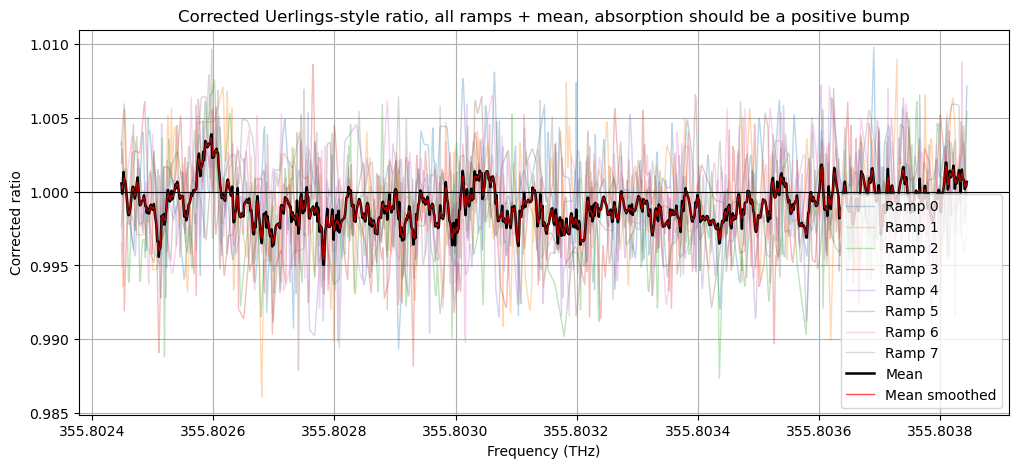

In [71]:
#Cell 10 - Ratio repeatability
plt.figure(figsize=(12, 5))
for i, y in enumerate(ratio_corr_matrix):
    plt.plot(common_x, y, alpha=0.3, lw=1, label=f"Ramp {i}" if i < 10 else None)

plt.plot(common_x, ratio_mean, color="black", lw=1.8, label="Mean")
plt.plot(common_x, ratio_mean_s, color="red", lw=1.0, alpha=0.7, label="Mean smoothed")
plt.axhline(1.0, color="black", lw=0.8)
plt.xlabel("Frequency (THz)")
plt.ylabel("Corrected ratio")
plt.title("Corrected Uerlings-style ratio, all ramps + mean, absorption should be a positive bump")
plt.legend()
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show()

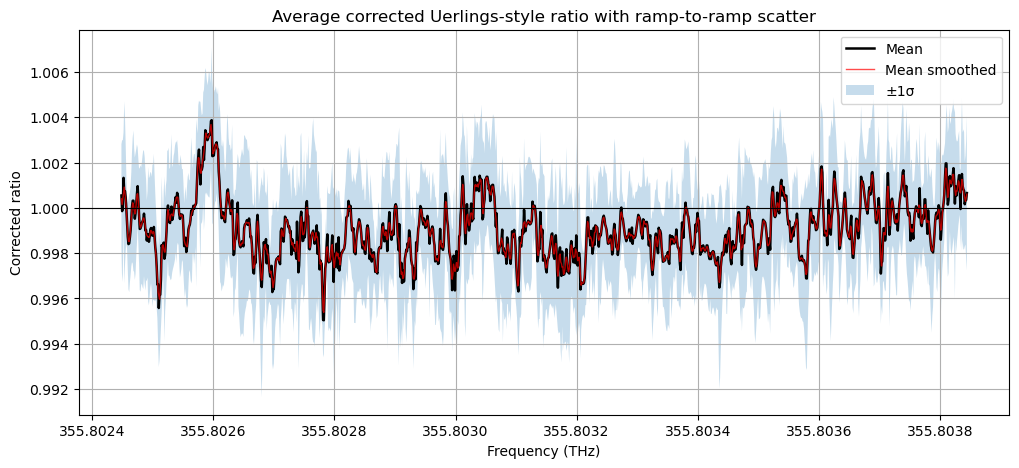

In [72]:
# Cell 11 - Mean + scatter band, ratio
plt.figure(figsize=(12, 5))
plt.plot(common_x, ratio_mean, color="black", lw=1.8, label="Mean")
plt.plot(common_x, ratio_mean_s, color="red", lw=1.0, alpha=0.7, label="Mean smoothed")
plt.fill_between(common_x, ratio_mean - ratio_std, ratio_mean + ratio_std, alpha=0.25, label="±1σ")
plt.axhline(1.0, color="black", lw=0.8)
plt.xlabel("Frequency (THz)")
plt.ylabel("Corrected ratio")
plt.title("Average corrected Uerlings-style ratio with ramp-to-ramp scatter")
plt.legend()
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show()

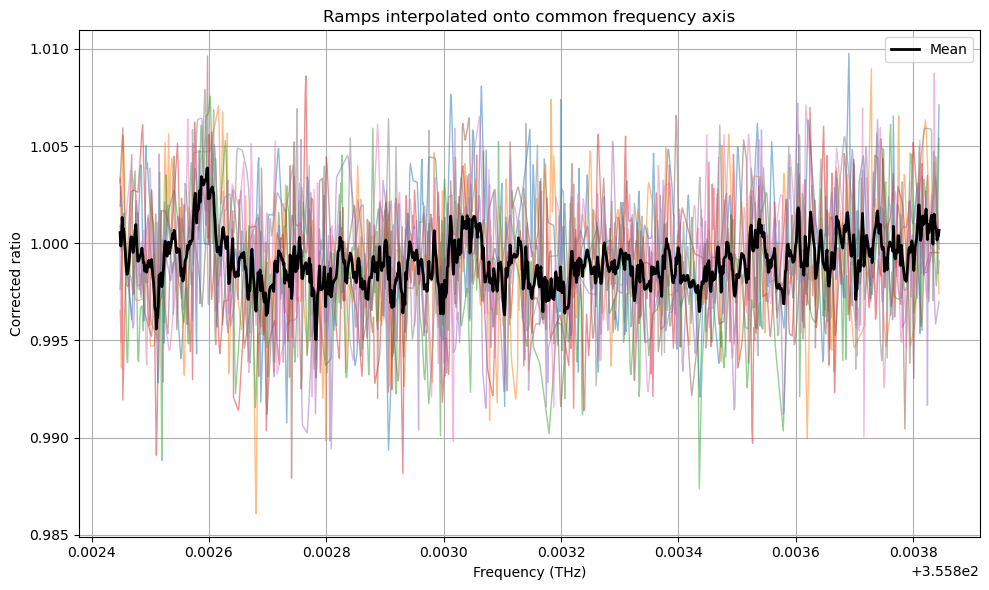

In [73]:
plt.figure(figsize=(10,6))
for i in range(len(processed)):
    plt.plot(common_x, ratio_corr_matrix[i], lw=1, alpha=0.5)
plt.plot(common_x, ratio_mean, color="black", lw=2, label="Mean")
plt.xlabel("Frequency (THz)")
plt.ylabel("Corrected ratio")
plt.title("Ramps interpolated onto common frequency axis")
plt.legend()
plt.tight_layout()
plt.show()

Found 10 OD-identified broad regions across the full scan
Stronger regions with OD area >= 30% of max area: 3

All candidates:

Peak 1
  Frequency         = 355.802448595 THz
  Region span     = 355.802448595 to 355.802485837 THz
  OD peak         = 0.000339
  OD area         = 2.118541e-08   (area SNR ≈ 0.23)
  Ratio local dip = 0.999717   (dip SNR ≈ 0.12)

Peak 2
  Frequency         = 355.802537045 THz
  Region span     = 355.802525407 to 355.802549847 THz
  OD peak         = 0.000225
  OD area         = 1.447129e-08   (area SNR ≈ 0.24)
  Ratio local dip = 0.998765   (dip SNR ≈ 0.51)

Peak 3
  Frequency         = 355.802596400 THz
  Region span     = 355.802562649 to 355.802634806 THz
  OD peak         = 0.003356
  OD area         = 1.472032e-07   (area SNR ≈ 0.75)
  Ratio local dip = 1.001094   (dip SNR ≈ -0.41)

Peak 4
  Frequency         = 355.803053782 THz
  Region span     = 355.803010720 to 355.803067747 THz
  OD peak         = 0.000967
  OD area         = 6.356069e-08   (area 

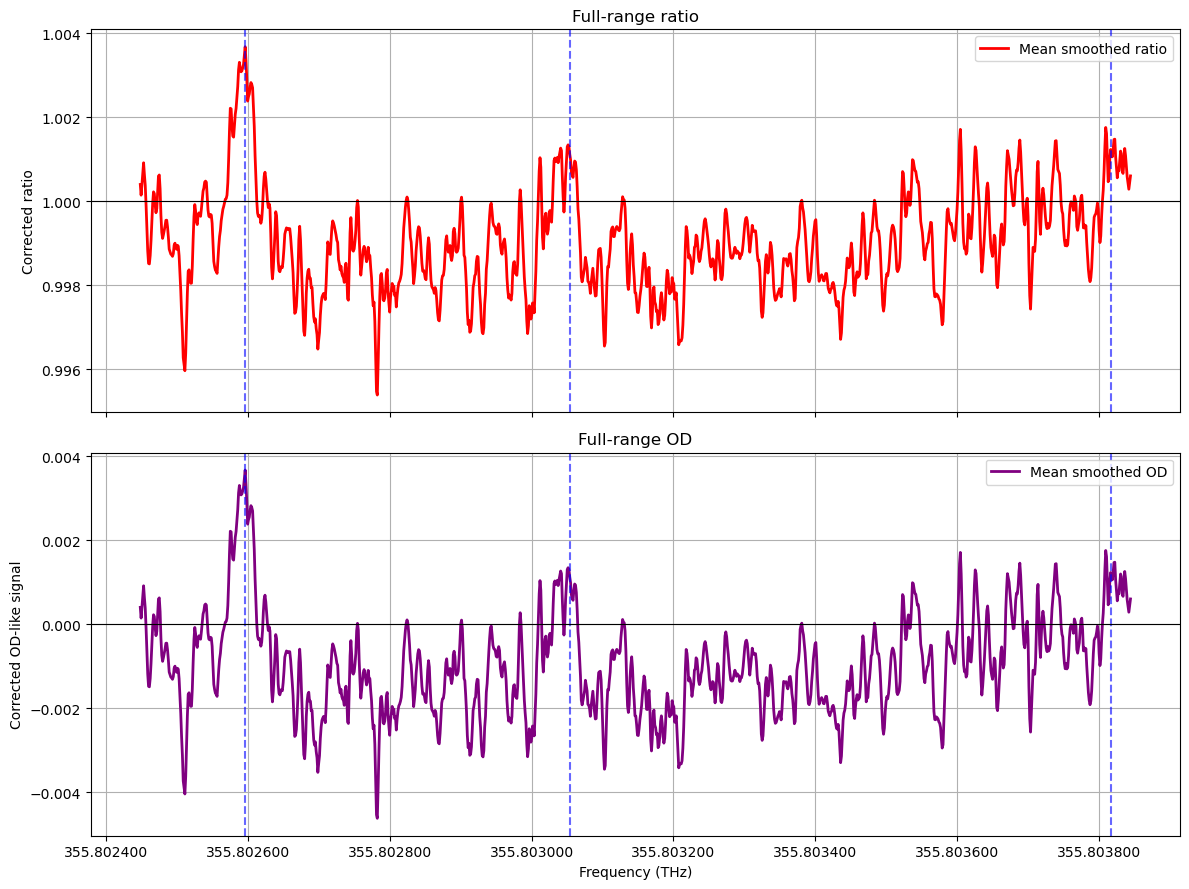

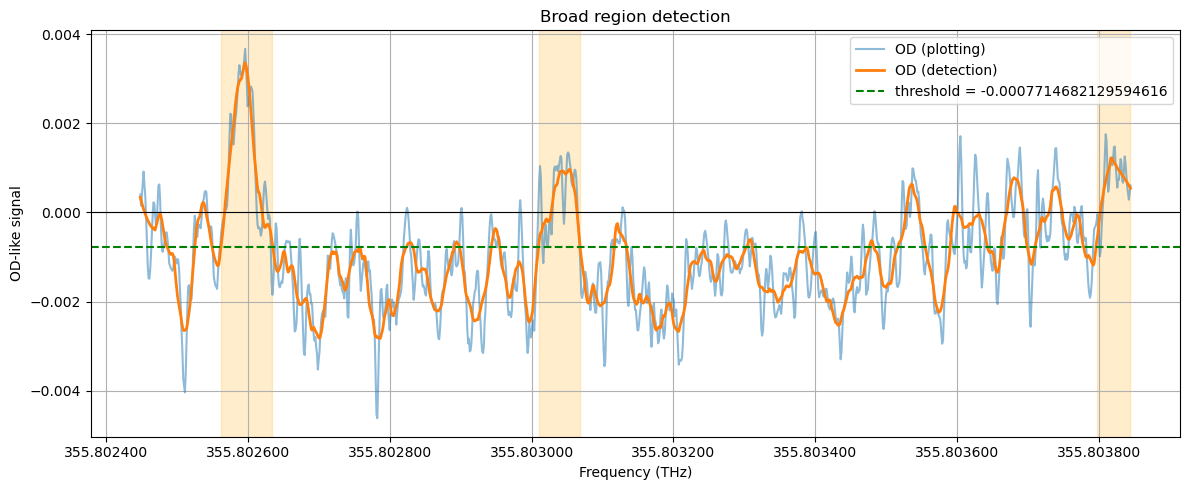

In [74]:
# Cell 12 - Full-range peak search using OD as primary detection
# Broad-feature detector using integrated OD area

from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Search the FULL common_x range
# -------------------------------------------------
x_search = common_x

ratio_search = ratio_mean
ratio_std_search = ratio_std

od_search = od_mean
od_std_search = od_std

detect_window = 31
detect_poly   = 2

ratio_detect = savgol_filter(ratio_search, detect_window, detect_poly)
od_detect    = savgol_filter(od_search,    detect_window, detect_poly)

# -------------------------------------------------
# 2. Detect broad OD regions
# -------------------------------------------------
baseline = np.percentile(od_detect, 40)
noise = np.std(od_detect - baseline)
threshold = baseline + 0.5 * noise
min_region_points = 12

above = od_detect > threshold

regions = []
in_region = False
start = None

for i, flag in enumerate(above):
    if flag and not in_region:
        start = i
        in_region = True
    elif not flag and in_region:
        end = i - 1
        if end - start + 1 >= min_region_points:
            regions.append((start, end))
        in_region = False

if in_region:
    end = len(above) - 1
    if end - start + 1 >= min_region_points:
        regions.append((start, end))

# -------------------------------------------------
# 3. Score regions by integrated OD area
# -------------------------------------------------
candidates = []
window = 12

for start, end in regions:
    region_slice = slice(start, end + 1)

    x_region = x_search[region_slice]
    od_region = od_detect[region_slice]
    od_std_region = od_std_search[region_slice]

    # representative peak position
    local_idx = np.argmax(od_region)
    op = start + local_idx

    x_o = x_search[op]
    y_od = od_detect[op]

    # integrated OD area above threshold
    od_excess = np.clip(od_region - threshold, 0, None)
    od_area = np.trapz(od_excess, x_region)

    # noise estimate
    mean_std = np.mean(od_std_region)
    region_width = x_region[-1] - x_region[0] if len(x_region) > 1 else 0.0
    od_area_noise = mean_std * max(region_width, 1e-12)

    area_snr = od_area / od_area_noise if od_area_noise > 0 else np.nan

    # ratio support
    i_min = max(0, op - window)
    i_max = min(len(ratio_search), op + window + 1)

    local_ratio = ratio_detect[i_min:i_max]
    local_ratio_std = ratio_std_search[i_min:i_max]

    ratio_val = np.min(local_ratio)
    ratio_noise = np.mean(local_ratio_std)
    snr_ratio_dip = (1.0 - ratio_val) / ratio_noise if ratio_noise > 0 else np.nan

    candidates.append({
        "x": x_o,
        "od": y_od,
        "od_area": od_area,
        "area_snr": area_snr,
        "ratio": ratio_val,
        "ratio_dip_snr": snr_ratio_dip,
        "region_start_x": x_search[start],
        "region_end_x": x_search[end]
    })

# -------------------------------------------------
# 4. Filter strong regions
# -------------------------------------------------
candidates = sorted(candidates, key=lambda d: d["x"])

# Keep the strongest regions by AREA, not SNR
candidates_sorted_by_area = sorted(candidates, key=lambda d: d["od_area"], reverse=True)

# take top N regions
max_area = candidates_sorted_by_area[0]["od_area"]

strong_peaks = [
    p for p in candidates_sorted_by_area
    if p["od_area"] >= 0.3 * max_area
]

# -------------------------------------------------
# 5. Print results
# -------------------------------------------------
print(f"Found {len(candidates)} OD-identified broad regions across the full scan")
print(f"Stronger regions with OD area >= 30% of max area: {len(strong_peaks)}\n")

print("All candidates:\n")
for i, p in enumerate(candidates):
    print(f"Peak {i+1}")
    print(f"  Frequency         = {p['x']:.9f} THz")
    print(f"  Region span     = {p['region_start_x']:.9f} to {p['region_end_x']:.9f} THz")
    print(f"  OD peak         = {p['od']:.6f}")
    print(f"  OD area         = {p['od_area']:.6e}   (area SNR ≈ {p['area_snr']:.2f})")
    print(f"  Ratio local dip = {p['ratio']:.6f}   (dip SNR ≈ {p['ratio_dip_snr']:.2f})")
    print()

print("Stronger peaks only:\n")
for i, p in enumerate(strong_peaks):
    print(f"Peak {i+1}")
    print(f"  Frequency         = {p['x']:.9f} THz")
    print(f"  Region span     = {p['region_start_x']:.9f} to {p['region_end_x']:.9f} THz")
    print(f"  OD peak         = {p['od']:.6f}")
    print(f"  OD area         = {p['od_area']:.6e}   (area SNR ≈ {p['area_snr']:.2f})")
    print(f"  Ratio local dip = {p['ratio']:.6f}   (dip SNR ≈ {p['ratio_dip_snr']:.2f})")
    print()

# -------------------------------------------------
# 6. Plot results
# -------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Ratio plot
ax[0].plot(common_x, ratio_mean_s, color="red", lw=2, label="Mean smoothed ratio")
for p in strong_peaks:
    ax[0].axvline(p["x"], color="blue", ls="--", alpha=0.6)
ax[0].axhline(1.0, color="black", lw=0.8)
ax[0].set_ylabel("Corrected ratio")
ax[0].set_title("Full-range ratio")
ax[0].legend()

# OD plot
ax[1].plot(common_x, od_mean_s, color="purple", lw=2, label="Mean smoothed OD")
for p in strong_peaks:
    ax[1].axvline(p["x"], color="blue", ls="--", alpha=0.6)
ax[1].axhline(0.0, color="black", lw=0.8)
ax[1].set_xlabel("Frequency (THz)")
ax[1].set_ylabel("Corrected OD-like signal")
ax[1].set_title("Full-range OD")
ax[1].legend()

plt.tight_layout()
ax[0].ticklabel_format(style='plain', axis='x', useOffset=False)
ax[1].ticklabel_format(style='plain', axis='x', useOffset=False)
ax[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.6f'))
plt.show()

# -------------------------------------------------
# 7. Diagnostic plot (VERY IMPORTANT)
# -------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(common_x, od_mean_s, label="OD (plotting)", alpha=0.5)
plt.plot(common_x, od_detect, label="OD (detection)", lw=2)

for p in strong_peaks:
    plt.axvspan(p["region_start_x"], p["region_end_x"], color="orange", alpha=0.2)

plt.axhline(threshold, color="green", ls="--", label=f"threshold = {threshold}")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Frequency (THz)")
plt.ylabel("OD-like signal")
plt.title("Broad region detection")
plt.legend()
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%.6f'))
plt.show()

Using strongest peak at f = 355.803053782 THz as the initial 1-peak fit target
Initial guess p0 = [0.0014214471866145217, 355.8030537815247, 2e-05]
Lower bounds     = [0.0, 355.8027537815247, 1e-06]
Upper bounds     = [0.05, 355.80335378152466, 0.0002]

1-peak fit results
------------------
Centre x0     = 355.803045796 ± 0.000006926 THz
Amplitude A   = 0.000991 ± 0.000583
Sigma         = 0.000009970 ± 0.000006689 THz
FWHM          = 0.000023477 ± 0.000015750 THz
Residual RMS  = 0.001760


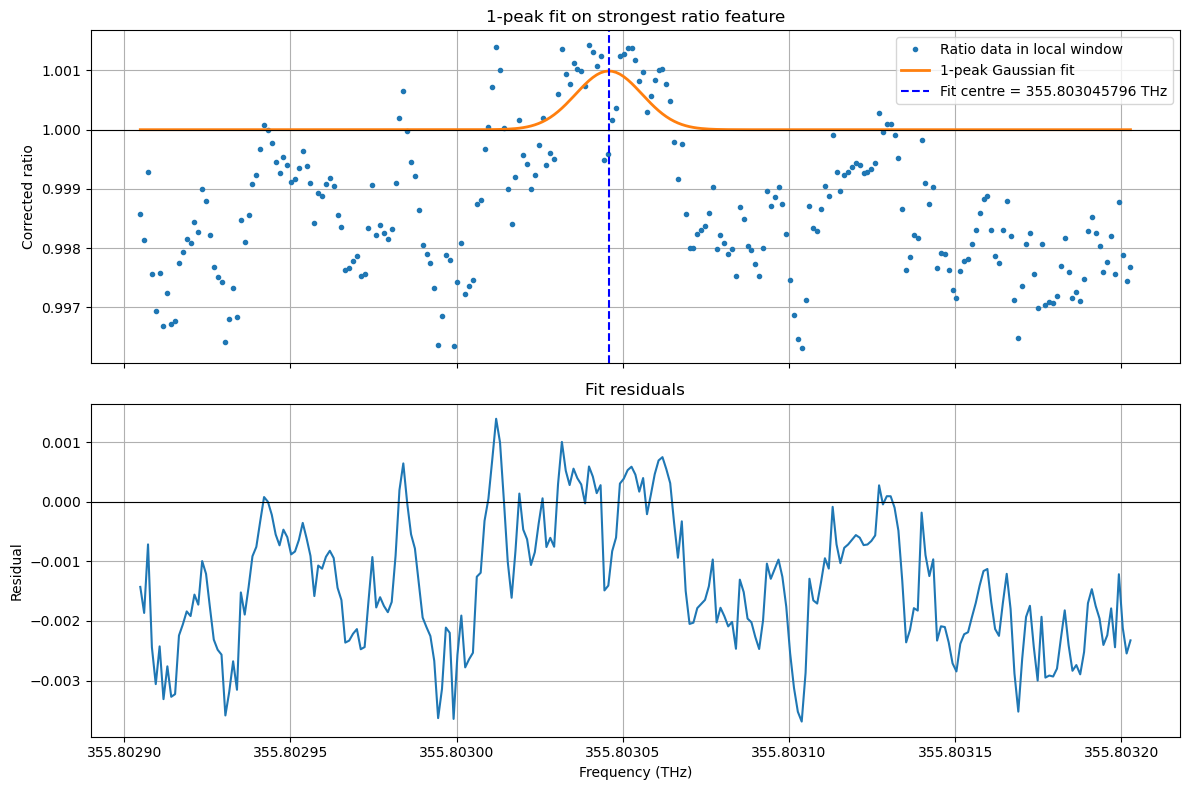

In [77]:
# Cell 13 - 1-peak Gaussian fit on the strongest ratio feature

from scipy.optimize import curve_fit

# -------------------------------------------------
# 1. Define model: one Gaussian bump on a fixed baseline of 1
# -------------------------------------------------
def gauss_only(x, A, x0, sigma):
    return 1.0 + A * np.exp(-0.5 * ((x - x0) / sigma) ** 2)

# -------------------------------------------------
# 2. Require at least one strong peak from Cell 12
# -------------------------------------------------
if len(strong_peaks) == 0:
    raise RuntimeError("No strong_peaks found in Cell 12, cannot do 1-peak fit.")

# Use the strongest ratio peak as the first fitting target
peak0 = max(strong_peaks, key=lambda p: p["ratio_dip_snr"])
x0_guess = peak0["x"]

print(f"Using strongest peak at f = {x0_guess:.9f} THz as the initial 1-peak fit target")

# -------------------------------------------------
# 3. Define a LOCAL fitting window around that peak
#    Keep this local so we are not trying to fit the whole scan at once
# -------------------------------------------------
fit_half_width = 0.00015  # THz

mask_fit = (common_x >= x0_guess - fit_half_width) & (common_x <= x0_guess + fit_half_width)

x_fit = common_x[mask_fit]
y_fit = ratio_mean[mask_fit]

if len(x_fit) < 20:
    raise RuntimeError("Fit window is too small. Check common_x or fit_half_width.")

# -------------------------------------------------
# 4. Initial guesses
# -------------------------------------------------
A_guess = max(y_fit - 1.0)

# THz-scale width guess
sigma_guess = 2e-5  # THz

lower_bounds = [
    0.0,                  # A
    x0_guess - 3e-4,      # x0
    1e-6                  # sigma
]

upper_bounds = [
    0.05,                 # A
    x0_guess + 3e-4,      # x0
    2e-4                  # sigma
]

# Force initial guess to be inside bounds
A_guess = np.clip(A_guess, lower_bounds[0] + 1e-9, upper_bounds[0] - 1e-9)
sigma_guess = np.clip(sigma_guess, lower_bounds[2] + 1e-9, upper_bounds[2] - 1e-9)

p0 = [A_guess, x0_guess, sigma_guess]

print("Initial guess p0 =", p0)
print("Lower bounds     =", lower_bounds)
print("Upper bounds     =", upper_bounds)

# -------------------------------------------------
# 6. Fit
# -------------------------------------------------
popt, pcov = curve_fit(
    gauss_only,
    x_fit,
    y_fit,
    p0=p0,
    bounds=(lower_bounds, upper_bounds),
    maxfev=20000
)

A_fit, x0_fit, sigma_fit = popt
y_model = gauss_only(x_fit, *popt)
resid = y_fit - y_model

# Gaussian FWHM
fwhm_fit = 2.35482 * sigma_fit

# crude uncertainties from covariance
perr = np.sqrt(np.diag(pcov))
A_err, x0_err, sigma_err = perr
fwhm_err = 2.35482 * sigma_err

# residual RMS
resid_rms = np.sqrt(np.mean(resid**2))

print("\n1-peak fit results")
print("------------------")
print(f"Centre x0     = {x0_fit:.9f} ± {x0_err:.9f} THz")
print(f"Amplitude A   = {A_fit:.6f} ± {A_err:.6f}")
print(f"Sigma         = {sigma_fit:.9f} ± {sigma_err:.9f} THz")
print(f"FWHM          = {fwhm_fit:.9f} ± {fwhm_err:.9f} THz")
print(f"Residual RMS  = {resid_rms:.6f}")

# -------------------------------------------------
# 7. Plot fit + residuals
# -------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(x_fit, y_fit, "o", ms=3, label="Ratio data in local window")
ax[0].plot(x_fit, y_model, "-", lw=2, label="1-peak Gaussian fit")
ax[0].axvline(x0_fit, color="blue", ls="--", label=f"Fit centre = {x0_fit:.9f} THz")
ax[0].axhline(1.0, color="black", lw=0.8)
ax[0].set_ylabel("Corrected ratio")
ax[0].set_title("1-peak fit on strongest ratio feature")
ax[0].legend()

ax[1].plot(x_fit, resid, "-", lw=1.5)
ax[1].axhline(0.0, color="black", lw=0.8)
ax[1].set_xlabel("Frequency (THz)")
ax[1].set_ylabel("Residual")
ax[1].set_title("Fit residuals")

plt.tight_layout()
ax[1].ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show()